## Stock Price Forecasting - HDFC Bank

### Raw data - Last 5 years

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
ticker = "HDFCBANK.NS"

# Last 5 years
end = datetime.today()
start = end - timedelta(days=5*365)

# Download with auto_adjust=False to get Adj Close separately
df = yf.download(
    ticker,
    start=start,
    end=end,
    progress=False,
    auto_adjust=False
)

df.reset_index(inplace=True)

# Convert datetime to date only
df['Date'] = df['Date'].dt.date

# Flatten column names if required
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

print(df.head())

# Save to Excel
df.to_excel("HDFC_5Y_raw_data.xlsx", index=False)
print("Saved as HDFC_5Y_raw_data.xlsx")

         Date   Adj Close       Close        High         Low        Open  \
0  2020-12-01  678.793457  716.650024  724.500000  712.750000  720.424988   
1  2020-12-02  666.314331  703.474976  715.900024  697.400024  715.500000   
2  2020-12-03  652.225220  688.599976  716.000000  687.025024  714.500000   
3  2020-12-04  656.203308  692.799988  700.724976  686.650024  690.500000   
4  2020-12-07  649.880920  686.125000  689.974976  679.049988  687.500000   

     Volume  
0  17147574  
1  17892150  
2  37933222  
3  26912322  
4  24316318  
Saved as HDFC_5Y_raw_data.xlsx


##Data Pre-processing & EDA

In [3]:
hdb = pd.read_excel('HDFC_5Y_raw_data.xlsx')
hdb.head(10)

,Date,Adj Close,Close,High,Low,Open,Volume
0,2020-12-01,678.793457,716.650024,724.500000,712.750000,720.424988,17147574
1,2020-12-02,666.314331,703.474976,715.900024,697.400024,715.500000,17892150
2,2020-12-03,652.225220,688.599976,716.000000,687.025024,714.500000,37933222
3,2020-12-04,656.203308,692.799988,700.724976,686.650024,690.500000,26912322
4,2020-12-07,649.880920,686.125000,689.974976,679.049988,687.500000,24316318
5,2020-12-08,651.798889,688.150024,694.400024,682.575012,687.500000,19457896
6,2020-12-09,666.432678,703.599976,705.025024,687.525024,688.500000,22069074
7,2020-12-10,656.321655,692.924988,701.000000,687.875000,699.000000,19727966
8,2020-12-11,654.877319,691.400024,697.500000,686.500000,695.025024,21356384
9,2020-12-14,649.833557,686.075012,694.000000,684.000000,691.500000,17222050


### Plot Adj Close Over Time

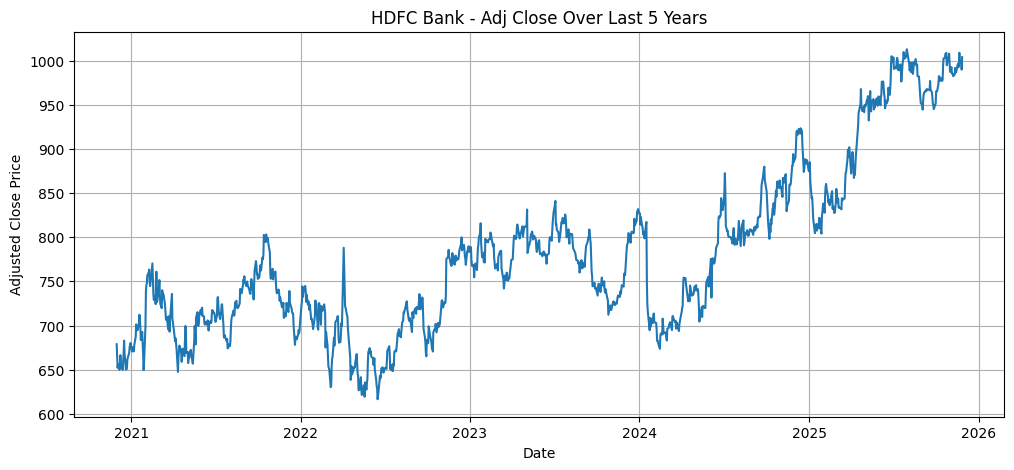

In [4]:
plt.figure(figsize=(12,5))
plt.plot(hdb['Date'], hdb['Adj Close'])
plt.title("HDFC Bank - Adj Close Over Last 5 Years")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.grid(True)
plt.show()

### Plot Volume Over Time

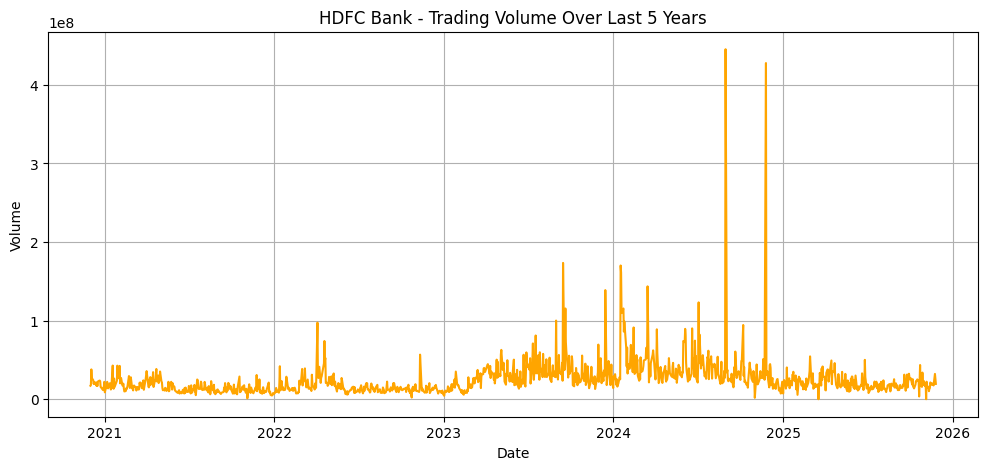

In [5]:
plt.figure(figsize=(12,5))
plt.plot(hdb['Date'], hdb['Volume'], color='orange')
plt.title("HDFC Bank - Trading Volume Over Last 5 Years")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()


### Summary Statistics

In [6]:
hdb.describe()

,Date,Adj Close,Close,High,Low,Open,Volume
count,1235,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1.235000e+03
mean,2023-05-30 08:43:31.821862400,780.072805,803.471863,810.254999,796.645042,803.354919,2.504938e+07
min,2020-12-01 00:00:00,616.520264,640.650024,648.200012,635.799988,637.500000,0.000000e+00
25%,2022-02-26 12:00:00,708.670105,741.237518,747.475006,733.537506,741.962494,1.314383e+07
50%,2023-05-30 00:00:00,764.230591,793.299988,800.250000,787.250000,793.950012,1.983350e+07
75%,2024-08-31 12:00:00,821.120331,839.975006,845.862488,833.975006,840.049988,3.092907e+07
max,2025-11-26 00:00:00,1012.900024,1012.900024,1020.500000,1008.500000,1018.849976,4.453421e+08
std,NaN,95.669382,86.932488,86.949742,87.103627,86.931418,2.423684e+07


### Missing Values and Duplicates

In [7]:
hdb.isnull().sum()


,0
Date,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
hdb.duplicated(subset='Date').sum()


np.int64(0)

In [8]:
hdb['Date'].is_monotonic_increasing


True

### Calculate and Plot Returns

In [9]:
#Current day Adj. close / Previous day Adj. close
hdb['Log_Returns'] = np.log(hdb['Adj Close'] / hdb['Adj Close'].shift(1))
hdb['Log_Returns']

,Log_Returns
0,NaN
1,-0.018555
2,-0.021372
3,0.006081
4,-0.009682
...,...
1230,0.014226
1231,-0.010763
1232,0.001102
1233,-0.009402


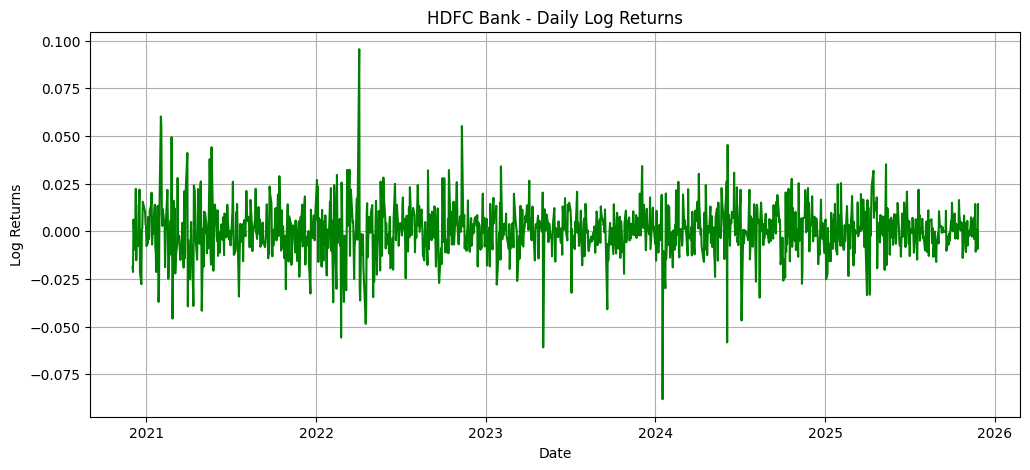

In [10]:
#Plotting the Adj. close returns over time
plt.figure(figsize=(12,5))
plt.plot(hdb['Date'], hdb['Log_Returns'], color='green')
plt.title("HDFC Bank - Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.grid(True)
plt.show()


### ACF & PACF of Log Returns

<Figure size 1200x400 with 0 Axes>

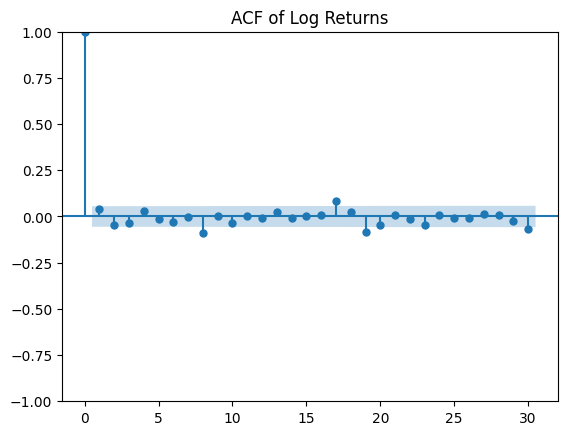

<Figure size 1200x400 with 0 Axes>

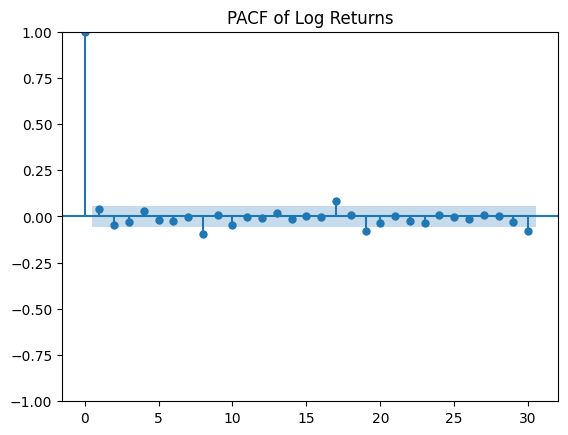

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Drop NaNs from the Log_Returns column
returns = hdb['Log_Returns'].dropna()

plt.figure(figsize=(12,4))
plot_acf(returns, lags=30)
plt.title("ACF of Log Returns")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(returns, lags=30)
plt.title("PACF of Log Returns")
plt.show()


### ADF Test on Price and Returns

In [12]:
from statsmodels.tsa.stattools import adfuller

# ADF Test for Adj Close
result_price = adfuller(hdb['Adj Close'].dropna())
print("ADF Test on Adj Close (Price Series)")
print(f"ADF Statistic: {result_price[0]}")
print(f"p-value: {result_price[1]}")
print("Critical Values:")
for key, value in result_price[4].items():
    print(f"   {key}: {value}")
print("\n")

# ADF Test for Log Returns
result_returns = adfuller(hdb['Log_Returns'].dropna())
print("ADF Test on Log Returns")
print(f"ADF Statistic: {result_returns[0]}")
print(f"p-value: {result_returns[1]}")
print("Critical Values:")
for key, value in result_returns[4].items():
    print(f"   {key}: {value}")


ADF Test on Adj Close (Price Series)
ADF Statistic: -1.0586368299309592
p-value: 0.7312821851553684
Critical Values:
   1%: -3.4356950607889254
   5%: -2.863900342696613
   10%: -2.568026681232353


ADF Test on Log Returns
ADF Statistic: -14.050129738443044
p-value: 3.1884169098128367e-26
Critical Values:
   1%: -3.4356950607889254
   5%: -2.863900342696613
   10%: -2.568026681232353


### Seasonal Decomposition (on Adj Close)

<Figure size 1200x800 with 0 Axes>

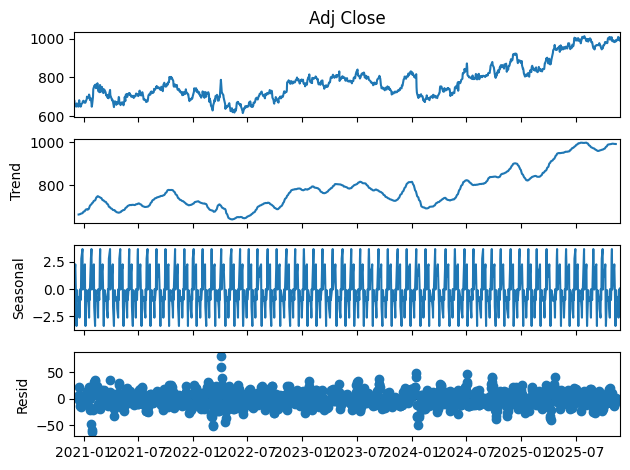

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set Date as index for decomposition
hdb_decomp = hdb.copy()
hdb_decomp['Date'] = pd.to_datetime(hdb_decomp['Date'])
hdb_decomp = hdb_decomp.set_index('Date')

# Decompose (additive model)
result = seasonal_decompose(hdb_decomp['Adj Close'], model='additive', period=21)

# Plot the decomposition
plt.figure(figsize=(12, 8))
result.plot()
plt.show()


## Pre-processing & Feature Engineering

### Adding lag variables (short-term memory to long term)

In [14]:
hdb['lag_1'] = hdb['Adj Close'].shift(1)
hdb['lag_2'] = hdb['Adj Close'].shift(2)
hdb['lag_5'] = hdb['Adj Close'].shift(5)
hdb['lag_10'] = hdb['Adj Close'].shift(10)
hdb['lag_21'] = hdb['Adj Close'].shift(21)

# Display sample
hdb[['Date', 'Adj Close', 'lag_1', 'lag_2', 'lag_5', 'lag_10', 'lag_21']].head(20)


,Date,Adj Close,lag_1,lag_2,lag_5,lag_10,lag_21
0,2020-12-01,678.793457,NaN,NaN,NaN,NaN,NaN
1,2020-12-02,666.314331,678.793457,NaN,NaN,NaN,NaN
2,2020-12-03,652.225220,666.314331,678.793457,NaN,NaN,NaN
3,2020-12-04,656.203308,652.225220,666.314331,NaN,NaN,NaN
4,2020-12-07,649.880920,656.203308,652.225220,NaN,NaN,NaN
5,2020-12-08,651.798889,649.880920,656.203308,678.793457,NaN,NaN
6,2020-12-09,666.432678,651.798889,649.880920,666.314331,NaN,NaN
7,2020-12-10,656.321655,666.432678,651.798889,652.225220,NaN,NaN
8,2020-12-11,654.877319,656.321655,666.432678,656.203308,NaN,NaN
9,2020-12-14,649.833557,654.877319,656.321655,649.880920,NaN,NaN


### Rolling Window Features

In [15]:
# Rolling Means
hdb['MA_5'] = hdb['Adj Close'].rolling(window=5).mean()
hdb['MA_10'] = hdb['Adj Close'].rolling(window=10).mean()
hdb['MA_21'] = hdb['Adj Close'].rolling(window=21).mean()

# Rolling Standard Deviations (Volatility)
hdb['VOL_5'] = hdb['Adj Close'].rolling(window=5).std()
hdb['VOL_10'] = hdb['Adj Close'].rolling(window=10).std()
hdb['VOL_21'] = hdb['Adj Close'].rolling(window=21).std()

hdb[['Date', 'Adj Close',
     'lag_1', 'lag_2', 'lag_5', 'lag_10', 'lag_21',
     'MA_5', 'MA_10', 'MA_21',
     'VOL_5', 'VOL_10', 'VOL_21'
    ]].head(25)

,Date,Adj Close,lag_1,lag_2,lag_5,lag_10,lag_21,MA_5,MA_10,MA_21,VOL_5,VOL_10,VOL_21
0,2020-12-01,678.793457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-12-02,666.314331,678.793457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-12-03,652.225220,666.314331,678.793457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-12-04,656.203308,652.225220,666.314331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-12-07,649.880920,656.203308,652.225220,NaN,NaN,NaN,660.683447,NaN,NaN,11.916241,NaN,NaN
5,2020-12-08,651.798889,649.880920,656.203308,678.793457,NaN,NaN,655.284534,NaN,NaN,6.580439,NaN,NaN
6,2020-12-09,666.432678,651.798889,649.880920,666.314331,NaN,NaN,655.308203,NaN,NaN,6.630057,NaN,NaN
7,2020-12-10,656.321655,666.432678,651.798889,652.225220,NaN,NaN,656.127490,NaN,NaN,6.403061,NaN,NaN
8,2020-12-11,654.877319,656.321655,666.432678,656.203308,NaN,NaN,655.862292,NaN,NaN,6.426552,NaN,NaN
9,2020-12-14,649.833557,654.877319,656.321655,649.880920,NaN,NaN,655.852820,658.268134,NaN,6.437598,9.381396,NaN


### Technical Indicators - RSI & EMA

In [16]:
# RSI Calculation (14-period)
window_length = 14

# Price differences
delta = hdb['Adj Close'].diff()

# Separate gains and losses
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Calculate rolling averages
avg_gain = gain.rolling(window=window_length).mean()
avg_loss = loss.rolling(window=window_length).mean()

# Compute RS
RS = avg_gain / avg_loss

# Compute RSI
hdb['RSI_14'] = 100 - (100 / (1 + RS))

In [17]:
# Exponential Moving Averages
hdb['EMA_10'] = hdb['Adj Close'].ewm(span=10, adjust=False).mean()
hdb['EMA_20'] = hdb['Adj Close'].ewm(span=20, adjust=False).mean()

hdb[['Date', 'Adj Close', 'RSI_14', 'EMA_10', 'EMA_20']].head(25)

,Date,Adj Close,RSI_14,EMA_10,EMA_20
0,2020-12-01,678.793457,NaN,678.793457,678.793457
1,2020-12-02,666.314331,NaN,676.524525,677.604969
2,2020-12-03,652.225220,NaN,672.106470,675.187850
3,2020-12-04,656.203308,NaN,669.214986,673.379798
4,2020-12-07,649.880920,NaN,665.699701,671.141810
5,2020-12-08,651.798889,NaN,663.172281,669.299627
6,2020-12-09,666.432678,NaN,663.765080,669.026584
7,2020-12-10,656.321655,NaN,662.411730,667.816591
8,2020-12-11,654.877319,NaN,661.041837,666.584279
9,2020-12-14,649.833557,NaN,659.003968,664.988973


### Target Creation (1-day and 30-day ahead)

In [18]:
# 1-day ahead log return (prediction target)
hdb['target_1d_return'] = hdb['Log_Returns'].shift(-1)


# 30-day ahead log return (long-term target)
hdb['target_30d_return'] = hdb['Log_Returns'].rolling(30).sum().shift(-30)


hdb[['Date', 'Adj Close', 'target_1d_return', 'target_30d_return']].head(20)


,Date,Adj Close,target_1d_return,target_30d_return
0,2020-12-01,678.793457,-0.018555,0.025725
1,2020-12-02,666.314331,-0.021372,0.042988
2,2020-12-03,652.225220,0.006081,0.062928
3,2020-12-04,656.203308,-0.009682,0.068001
4,2020-12-07,649.880920,0.002947,0.091577
5,2020-12-08,651.798889,0.022203,0.080719
6,2020-12-09,666.432678,-0.015288,0.046921
7,2020-12-10,656.321655,-0.002203,0.040792
8,2020-12-11,654.877319,-0.007732,0.056276
9,2020-12-14,649.833557,0.013860,0.026927


In [19]:
hdb = hdb.drop(columns=['target_1d', 'target_30d'], errors='ignore')

### Scaling to suit ML models

In [20]:
ml_df = hdb.copy() #making a copy as the original hdb will be used for ARIMA as well

In [21]:
ml_df = ml_df.dropna().reset_index(drop=True) #dropping all NaNs which were introduced during feature enginnering
ml_df.shape

(1184, 24)

Features: Log_Returns
lag_1, lag_2, lag_5, lag_10, lag_21
MA_5, MA_10, MA_21
VOL_5, VOL_10, VOL_21
RSI_14
EMA_10, EMA_20


targets: target_1d, target_30d


In [22]:
#extracting feature and target columns
feature_cols = [
    'Log_Returns',
    'lag_1', 'lag_2', 'lag_5', 'lag_10', 'lag_21',
    'MA_5', 'MA_10', 'MA_21',
    'VOL_5', 'VOL_10', 'VOL_21',
    'RSI_14',
    'EMA_10', 'EMA_20'
]

X = ml_df[feature_cols]
y1 = ml_df['target_1d_return']
y30 = ml_df['target_30d_return']


In [23]:
#Scaling the entire feature data columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [24]:
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

##Model 1: ARIMA (does not use scaled dataset)

### Preparing price series

<Axes: title={'center': 'HDFC Bank - Adj Close (Original Price)'}, xlabel='Date'>

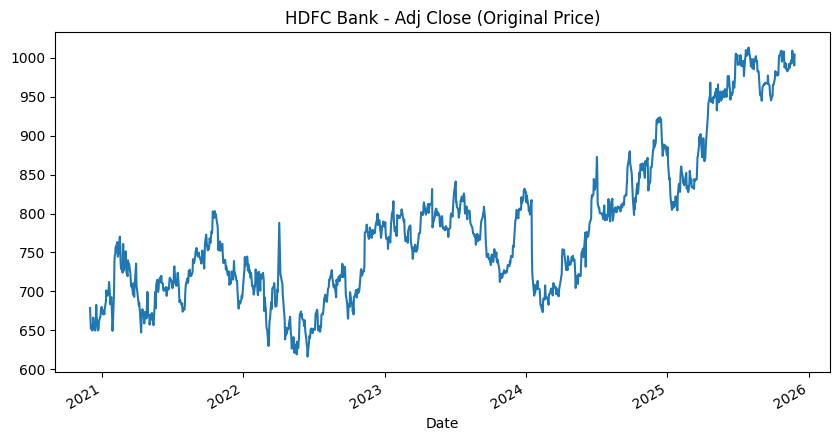

In [25]:
# Extract Adj Close for ARIMA
price = hdb[['Date', 'Adj Close']].copy()

# Make Date the index
price['Date'] = pd.to_datetime(price['Date'])
price = price.set_index('Date')

# Plot original series
price['Adj Close'].plot(figsize=(10,5), title="HDFC Bank - Adj Close (Original Price)")


### Differencing

<Axes: title={'center': '1st Differenced Series (Adj Close)'}, xlabel='Date'>

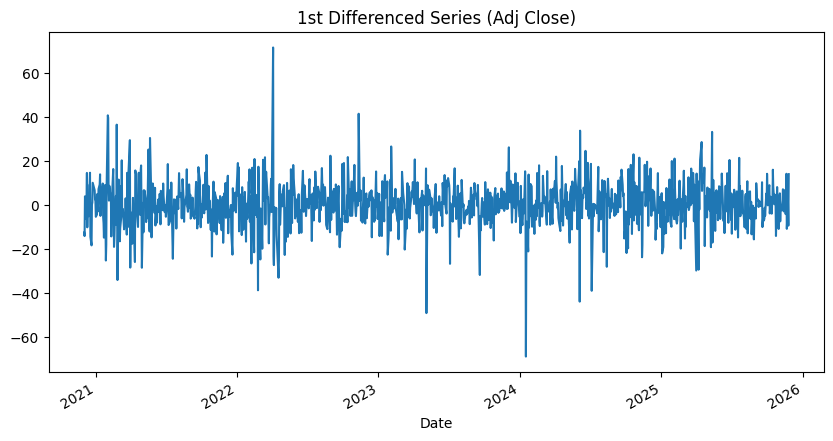

In [26]:
# 1st difference to remove trend
price['diff_1'] = price['Adj Close'].diff()
price['diff_1'].plot(figsize=(10,5), title="1st Differenced Series (Adj Close)")


### ADF test on differenced series

In [27]:
from statsmodels.tsa.stattools import adfuller

diff_data = price['diff_1'].dropna()

result = adfuller(diff_data)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -14.026179992408574
p-value: 3.500074757165865e-26
Critical Values:
   1%: -3.4356950607889254
   5%: -2.863900342696613
   10%: -2.568026681232353


### ACF/PACF on differenced series

<Figure size 1200x400 with 0 Axes>

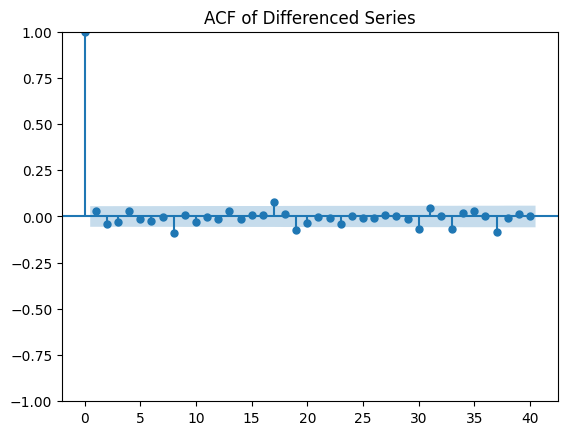

<Figure size 1200x400 with 0 Axes>

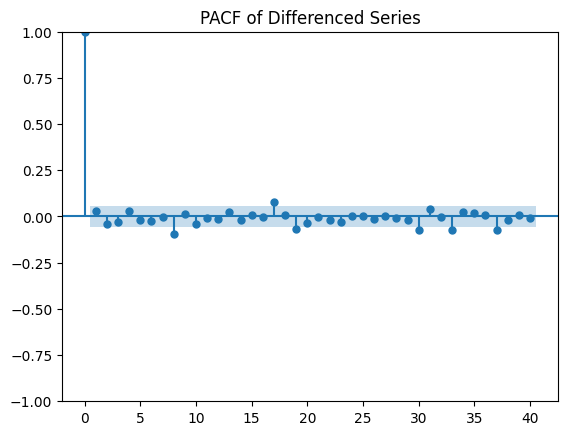

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Drop NaN created by differencing
diff_data = price['diff_1'].dropna()

plt.figure(figsize=(12,4))
plot_acf(diff_data, lags=40)
plt.title("ACF of Differenced Series")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(diff_data, lags=40, method='ywm')
plt.title("PACF of Differenced Series")
plt.show()


Based on the above plots it is confirmed by ADF test that for ARIMA (significant lag only at lag 1):
* p = 1
* d = 1  
* q = 1

### ARIMA model

In [29]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Extract the Adj Close series
series = price['Adj Close']

# Fit ARIMA(1,1,1)
model = ARIMA(series, order=(1,1,1))
model_fit = model.fit()

# Model summary
print(model_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 1235
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4618.500
Date:                Thu, 27 Nov 2025   AIC                           9243.000
Time:                        15:25:03   BIC                           9258.354
Sample:                             0   HQIC                          9248.776
                               - 1235                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2624      0.678     -0.387      0.699      -1.592       1.067
ma.L1          0.2970      0.674      0.441      0.659      -1.024       1.618
sigma2       104.2984      2.311     45.122      0.0

Not a great result, as coefficients are not significant and AIC is very high, expected for stock data but let's try auto-arima

### Auto ARIMA

In [30]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 33.6 MB/s eta 0:00:00


In [31]:
from pmdarima import auto_arima

# Auto ARIMA on Adj Close price
auto_model = auto_arima(
    price['Adj Close'],
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=1,               # already confirmed using ADF
    seasonal=False,    # no seasonality in stock prices
    trace=True,        # prints the models being tested
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9241.763, Time=0.16 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9242.732, Time=0.36 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9242.648, Time=0.81 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9240.583, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9244.221, Time=3.85 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 5.331 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1235
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4619.292
Date:                Thu, 27 Nov 2025   AIC                           9240.583
Time:                        15:25:25   BIC                           9245.701
Sample:                             0   HQIC                          9242.509
                               - 1235                                       

### Forecast using auto ARIMA ( short term and long term)

In [32]:
#short term (1 day)
forecast_1d = auto_model.predict(n_periods=1).tolist()[0]
print("1-Day Ahead Forecast:", forecast_1d)

1-Day Ahead Forecast: 1003.900024414062


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [33]:
#Long term (30 days)
forecast_30d = auto_model.predict(n_periods=30)
print("30-Day Forecast:", forecast_30d)

30-Day Forecast: 1235    1003.900024
1236    1003.900024
1237    1003.900024
1238    1003.900024
1239    1003.900024
1240    1003.900024
1241    1003.900024
1242    1003.900024
1243    1003.900024
1244    1003.900024
1245    1003.900024
1246    1003.900024
1247    1003.900024
1248    1003.900024
1249    1003.900024
1250    1003.900024
1251    1003.900024
1252    1003.900024
1253    1003.900024
1254    1003.900024
1255    1003.900024
1256    1003.900024
1257    1003.900024
1258    1003.900024
1259    1003.900024
1260    1003.900024
1261    1003.900024
1262    1003.900024
1263    1003.900024
1264    1003.900024
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Vizualising the forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


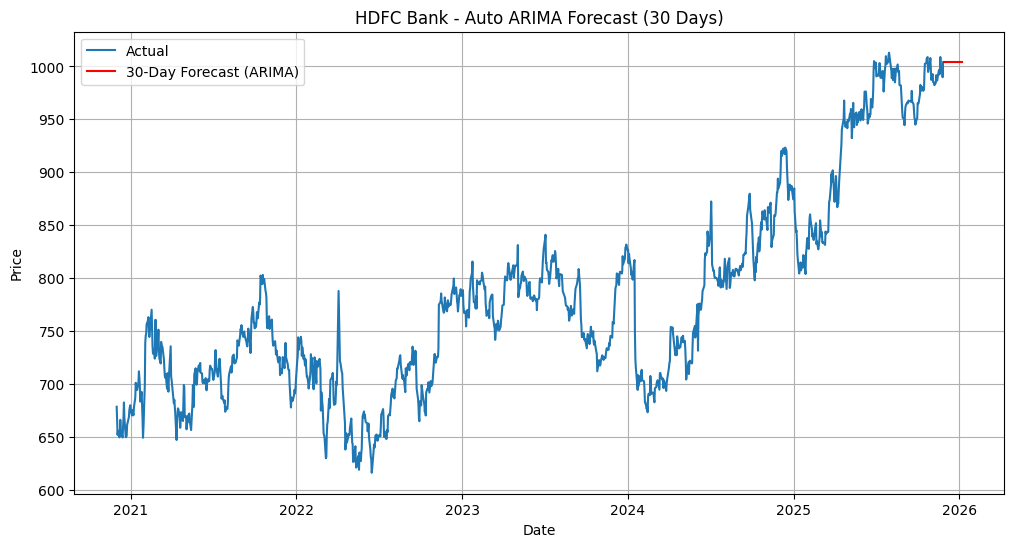

In [34]:
forecast_30d = auto_model.predict(n_periods=30)
forecast_30d = forecast_30d.tolist()

# Create future business day index
future_dates = pd.date_range(
    start=price.index[-1],
    periods=31,
    freq='B'
)[1:]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot historical prices
plt.plot(price.index, price['Adj Close'], label="Actual")

# Plot the ARIMA forecast
plt.plot(future_dates, forecast_30d, label="30-Day Forecast (ARIMA)", color='red')

plt.title("HDFC Bank - Auto ARIMA Forecast (30 Days)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


* ARIMA was implemented as a classical time-series baseline, it failed to perform well for HDFC Bank stock prices. We tried manual as well as auto, the Auto ARIMA procedure selected ARIMA(0,1,0) as the best model, which turns out to be a random walk.  

* This shows that the past price movements (AR or MA) do not  explain future changes, and the best forecast for the next day is the last price with some random noise

* As a result, the ARIMA forecast shows a flat line, offering minimal predictive power. This outcome is expected for financial markets, which often behave as efficient random walks, and highlights the need for more expressive ML models that can utilize richer feature sets (lags, rolling statistics, RSI, EMA, etc.) for better forecasting performance

* We will go for ML modeles and not use ARIMA going forward in this project

# Model 2: XGboost

## Short term prediction (1 Day)

We already have the below from pre-processing step:
* X → raw feature matrix
* X_scaled → scaled feature matrix
* y1 → 1-day ahead target
* y30 → 30-day ahead target

### Train and Test split (Chronologically splitting the last 10% of the data as test and the reaming is used to training)

In [35]:
#Splitlling the data to train/test

from sklearn.model_selection import train_test_split

# Time-series aware split → shuffle=False
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y1,
    test_size=0.1,
    shuffle=False
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (1065, 15)
X_test: (119, 15)


### XGboost model: Train

In [36]:
!pip install xgboost


In [38]:
from xgboost import XGBRegressor

# Initialize the model
xgb_model = XGBRegressor(
    n_estimators=300,      # number of boosted trees
    learning_rate=0.05,   # step size shrinkage
    max_depth=5,          # depth of individual trees
    subsample=0.8,        # row sampling
    colsample_bytree=0.8, # feature sampling
    objective='reg:squarederror',
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### XGboost model: Test

In [39]:
# Predict on the test set
y_pred_return = xgb_model.predict(X_test)

print("Predictions done!")

# Show first few predicted vs actual values
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_return
})

comparison_df.head(10)

Predictions done!


,Actual,Predicted
0,0.004698,0.002698
1,-0.005954,-0.003109
2,0.008451,-0.002156
3,-0.001612,-0.005874
4,0.007723,-0.011542
5,-0.002637,-0.008402
6,0.007170,-0.008629
7,-0.008828,-0.004678
8,-0.020324,-0.002988
9,0.035097,-0.013818


In [41]:
#Converting the predicted returns back to price

import numpy as np

# previous day's price
prev_price = hdb['Adj Close'].shift(1).iloc[y_test.index]

# convert returns → price
y_pred_price = prev_price * np.exp(y_pred_return)

# actual next-day price
y_actual_price = hdb['Adj Close'].iloc[y_test.index]

### Evaluation

### 1-Day Ahead Forecast (Actual vs Predicted Price)

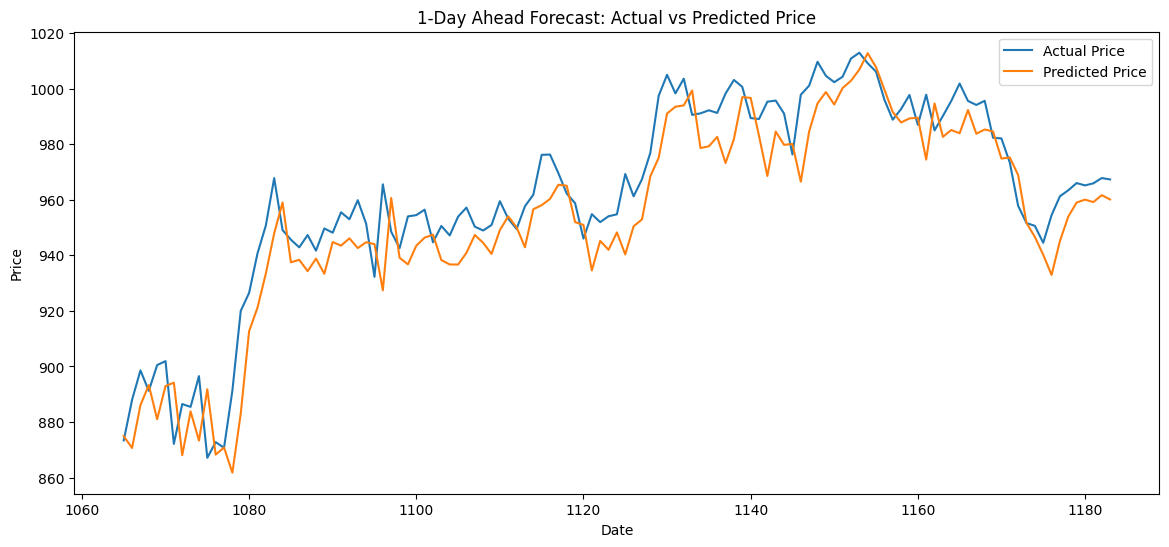

In [42]:
#Vizualizing 1 day actual vs forecast
test_index = y_test.index

plt.figure(figsize=(14,6))
plt.plot(test_index, y_actual_price, label="Actual Price")
plt.plot(test_index, y_pred_price, label="Predicted Price")

plt.title("1-Day Ahead Forecast: Actual vs Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


### Feature imporance ratings

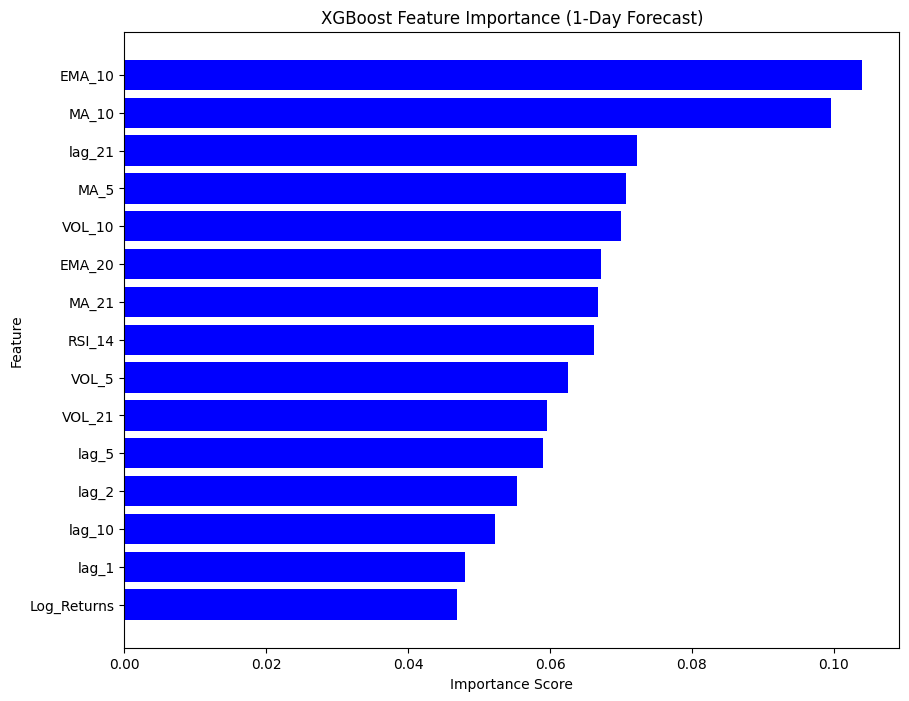

In [43]:
# Get feature importance scores
importance = xgb_model.feature_importances_

# Create a DataFrame for better readability
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='blue')
plt.title("XGBoost Feature Importance (1-Day Forecast)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


## Long term prediction (30 days)

### Train and Test split (Chronologically splitting the last 10% of the data as test and the reaming is used to training)

In [44]:
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X_scaled, y30, test_size=0.2, shuffle=False
)

### XGboost model: Train

In [45]:
xgb_model_30 = XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.05,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_30.fit(X_train_30, y_train_30)

print("XGBoost model trained successfully.")


XGBoost model trained successfully.


### XGboost model: Test

In [46]:
y_pred_30_return = xgb_model_30.predict(X_test_30)


In [47]:
#Converting the predicted returns back to price

import numpy as np
prev_price_30 = hdb['Adj Close'].iloc[y_test_30.index]

y_pred_30_price = prev_price_30 * np.exp(y_pred_30_return)

y_actual_30_price = hdb['Adj Close'].shift(-30).iloc[y_test_30.index]


### Evaluation

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_30 = np.sqrt(mean_squared_error(y_actual_30_price, y_pred_30_price))
mae_30  = mean_absolute_error(y_actual_30_price, y_pred_30_price)
mape_30 = (np.abs((y_actual_30_price - y_pred_30_price) / y_actual_30_price).mean()) * 100

print("\n30-Day Ahead Price Prediction Evaluation:")
print("----------------------------------------")
print(f"RMSE (30d): {rmse_30:.4f}")
print(f"MAE  (30d): {mae_30:.4f}")
print(f"MAPE (30d): {mape_30:.2f}%")



30-Day Ahead Price Prediction Evaluation:
----------------------------------------
RMSE (30d): 53.3806
MAE  (30d): 41.2105
MAPE (30d): 4.57%


### 30-Day Ahead Forecast (Actual vs Predicted Price)

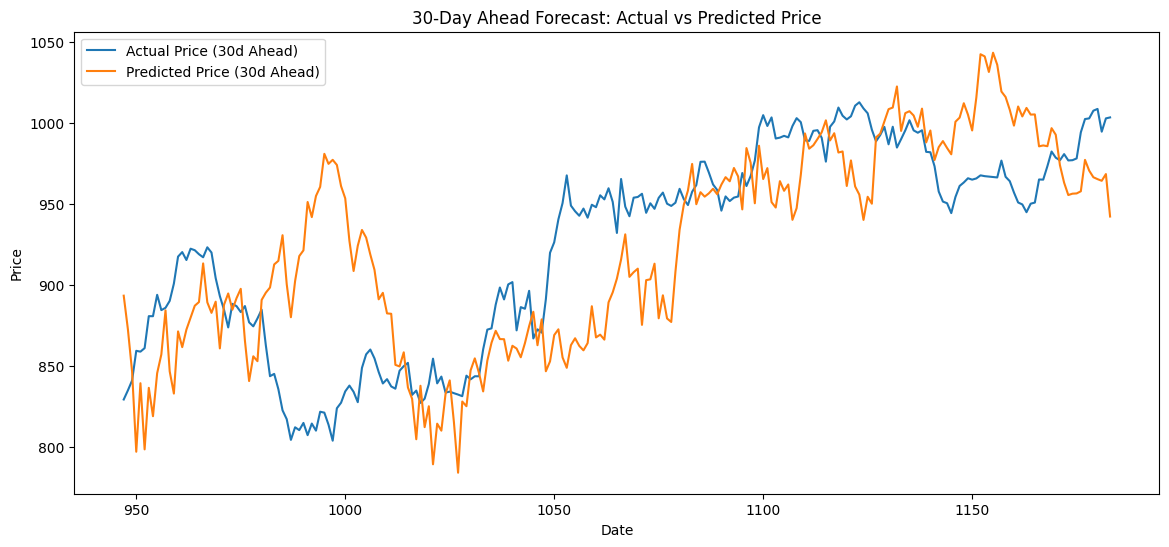

In [49]:
#Vizualizing 30 day actual vs forecast
test_index_30 = y_test_30.index

plt.figure(figsize=(14,6))
plt.plot(test_index_30, y_actual_30_price, label="Actual Price (30d Ahead)")
plt.plot(test_index_30, y_pred_30_price, label="Predicted Price (30d Ahead)")

plt.title("30-Day Ahead Forecast: Actual vs Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


### Feature importance rating

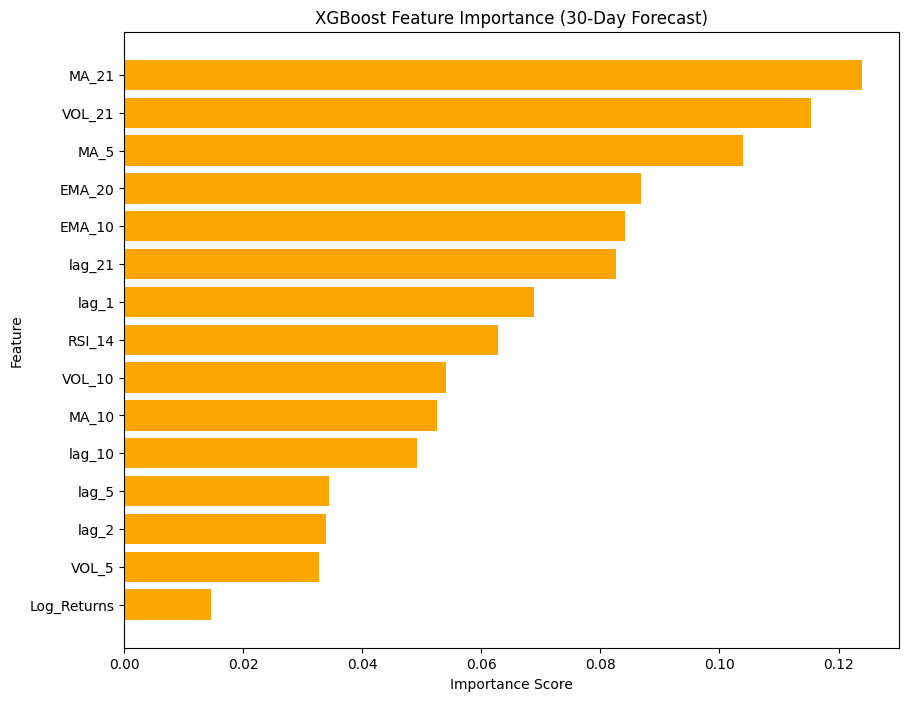

In [50]:
# Get feature importance scores
importance = xgb_model_30.feature_importances_

# Create a DataFrame for better readability
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='orange')
plt.title("XGBoost Feature Importance (30-Day Forecast)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [51]:
ml_df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Log_Returns', 'lag_1', 'lag_2', 'lag_5', 'lag_10', 'lag_21', 'MA_5',
       'MA_10', 'MA_21', 'VOL_5', 'VOL_10', 'VOL_21', 'RSI_14', 'EMA_10',
       'EMA_20', 'target_1d_return', 'target_30d_return'],
      dtype='object')

In [52]:
import pickle

# Save short-term model
pickle.dump(xgb_model, open("xgb_1d.pkl", "wb"))

# Save long-term model
pickle.dump(xgb_model_30, open("xgb_30d.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))


## Pipeline (step-wise)

### Building the preprocessing function for NEW incoming data

In [53]:
# Constructing a pipeline which does all the feature enginnering which was done in Pre-proceesing on historical data

import pandas as pd
import numpy as np

def preprocess_new_data(df, scaler):
    """
    Preprocess raw Yahoo stock data and return the last row of ML-ready features.
    Used for pipeline prediction.
    """

    df = df.copy()

    # 1. Basic sorting
    df = df.sort_index()

    # 2. Log Returns
    df['Log_Returns'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

    # 3. Lag features
    df['lag_1'] = df['Log_Returns'].shift(1)
    df['lag_2'] = df['Log_Returns'].shift(2)
    df['lag_5'] = df['Log_Returns'].shift(5)
    df['lag_10'] = df['Log_Returns'].shift(10)
    df['lag_21'] = df['Log_Returns'].shift(21)

    # 4. Moving averages (price)
    df['MA_5'] = df['Adj Close'].rolling(5).mean()
    df['MA_10'] = df['Adj Close'].rolling(10).mean()
    df['MA_21'] = df['Adj Close'].rolling(21).mean()

    # 5. Volume moving averages
    df['VOL_5'] = df['Volume'].rolling(5).mean()
    df['VOL_10'] = df['Volume'].rolling(10).mean()
    df['VOL_21'] = df['Volume'].rolling(21).mean()

    # 6. RSI
    delta = df['Adj Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    RS = avg_gain / avg_loss
    df['RSI_14'] = 100 - (100 / (1 + RS))

    # 7. EMA
    df['EMA_10'] = df['Adj Close'].ewm(span=10, adjust=False).mean()
    df['EMA_20'] = df['Adj Close'].ewm(span=20, adjust=False).mean()

    # 8. Drop NaNs created from rolling windows
    df = df.dropna()

    # 9. Select final ML features
    feature_cols = [
        'Log_Returns',
        'lag_1', 'lag_2', 'lag_5', 'lag_10', 'lag_21',
        'MA_5', 'MA_10', 'MA_21',
        'VOL_5', 'VOL_10', 'VOL_21',
        'RSI_14',
        'EMA_10', 'EMA_20'
    ]

    X_all = df[feature_cols]

    # 10. Scale using the SAME scaler used during training
    X_scaled_all = scaler.transform(X_all)

    # 11. Get the LAST row (most recent feature vector)
    last_features_scaled = X_scaled_all[-1].reshape(1, -1)

    # 12. Get latest actual price for converting return → price
    last_price = df['Adj Close'].iloc[-1]

    return last_features_scaled, last_price


### Loading the trained models

In [54]:
import pickle

def load_models():
    """
    Loads the trained XGBoost models and scaler.
    """
    xgb_1d = pickle.load(open("xgb_1d.pkl", "rb"))
    xgb_30d = pickle.load(open("xgb_30d.pkl", "rb"))
    scaler = pickle.load(open("scaler.pkl", "rb"))

    print("Models and scaler loaded successfully")
    return xgb_1d, xgb_30d, scaler


In [55]:
# Testing if models are loaded succesfully
xgb_1d, xgb_30d, scaler = load_models()


Models and scaler loaded successfully


### The Core Prediction Engine

In [56]:
def make_forecast(last_features_scaled, last_price, xgb_1d, xgb_30d):
    """
    Uses the trained XGBoost models to generate:
    - 1-day ahead predicted return & price
    - 30-day ahead predicted return & price
    """

    # 1. Predict 1-day ahead RETURN
    pred_return_1d = xgb_1d.predict(last_features_scaled)[0]

    # Convert return → predicted price
    pred_price_1d = last_price * np.exp(pred_return_1d)

    # 2. Predict 30-day ahead RETURN
    pred_return_30d = xgb_30d.predict(last_features_scaled)[0]

    # Convert return → predicted 30-day price
    pred_price_30d = last_price * np.exp(pred_return_30d)

    # 3. Return all results in a clean dictionary
    results = {
        "last_price": float(last_price),

        "predicted_return_1d": float(pred_return_1d),
        "predicted_price_1d": float(pred_price_1d),

        "predicted_return_30d": float(pred_return_30d),
        "predicted_price_30d": float(pred_price_30d)
    }

    return results


### The Final Pipeline Function

In [57]:
import yfinance as yf

def run_pipeline(ticker):
    """
    End-to-end pipeline:
    1. Download data
    2. Preprocess features
    3. Load models + scaler
    4. Predict short-term & long-term
    5. Print results nicely
    """

    print(f"\nFetching data for {ticker}...")
    df = yf.download(ticker, period="5y", interval="1d", auto_adjust=False)

    if df.empty:
        print("Error: Could not download data. Check ticker symbol.")
        return

    # ---- Load models & scaler ----
    xgb_1d, xgb_30d, scaler = load_models()

    # ---- Preprocess (Step 1) ----
    last_features_scaled, last_price = preprocess_new_data(df, scaler)

    # ---- Forecast (Step 3) ----
    results = make_forecast(last_features_scaled, last_price, xgb_1d, xgb_30d)

    # ---- Pretty Output ----
    print("\n=================== STOCK FORECAST RESULT ===================")
    print(f"Ticker: {ticker}")
    print("--------------------------------------------------------------")
    print(f"Last Available Price:        ₹{results['last_price']:.2f}")
    print("--------------------------------------------------------------")
    print(f"Predicted 1-Day Return:      {results['predicted_return_1d']*100:.3f}%")
    print(f"Predicted 1-Day Price:       ₹{results['predicted_price_1d']:.2f}")
    print("--------------------------------------------------------------")
    print(f"Predicted 30-Day Return:     {results['predicted_return_30d']*100:.3f}%")
    print(f"Predicted 30-Day Price:      ₹{results['predicted_price_30d']:.2f}")
    print("==============================================================\n")

    return results


### Testing on various stocks

In [58]:
run_pipeline("HDFCBANK.NS")

[*********************100%***********************]  1 of 1 completed


Fetching data for HDFCBANK.NS...
Models and scaler loaded successfully

=================== STOCK FORECAST RESULT ===================
Ticker: HDFCBANK.NS
--------------------------------------------------------------
Last Available Price:        ₹1009.50
--------------------------------------------------------------
Predicted 1-Day Return:      -1.190%
Predicted 1-Day Price:       ₹997.56
--------------------------------------------------------------
Predicted 30-Day Return:     -6.352%
Predicted 30-Day Price:      ₹947.37




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1461305373.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "last_price": float(last_price),
/tmp/ipython-input-1461305373.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_1d": float(pred_price_1d),
/tmp/ipython-input-1461305373.py:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_30d": float(pred_price_30d)


{'last_price': 1009.5,
 'predicted_return_1d': -0.011895417235791683,
 'predicted_price_1d': 997.5627575218678,
 'predicted_return_30d': -0.06352142244577408,
 'predicted_price_30d': 947.3693452477455}

In [59]:
run_pipeline("ICICIBANK.NS")
run_pipeline("SBIN.NS")
run_pipeline("RELIANCE.NS")


Fetching data for ICICIBANK.NS...


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1461305373.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "last_price": float(last_price),
/tmp/ipython-input-1461305373.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_1d": float(pred_price_1d),
/tmp/ipython-input-1461305373.py:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_30d": float(pred_price_30d)


Models and scaler loaded successfully

=================== STOCK FORECAST RESULT ===================
Ticker: ICICIBANK.NS
--------------------------------------------------------------
Last Available Price:        ₹1392.20
--------------------------------------------------------------
Predicted 1-Day Return:      -1.624%
Predicted 1-Day Price:       ₹1369.77
--------------------------------------------------------------
Predicted 30-Day Return:     -5.872%
Predicted 30-Day Price:      ₹1312.80


Fetching data for SBIN.NS...


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1461305373.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "last_price": float(last_price),
/tmp/ipython-input-1461305373.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_1d": float(pred_price_1d),
/tmp/ipython-input-1461305373.py:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_30d": float(pred_price_30d)


Models and scaler loaded successfully

=================== STOCK FORECAST RESULT ===================
Ticker: SBIN.NS
--------------------------------------------------------------
Last Available Price:        ₹972.85
--------------------------------------------------------------
Predicted 1-Day Return:      -1.951%
Predicted 1-Day Price:       ₹954.05
--------------------------------------------------------------
Predicted 30-Day Return:     -5.768%
Predicted 30-Day Price:      ₹918.32


Fetching data for RELIANCE.NS...


[*********************100%***********************]  1 of 1 completed

Models and scaler loaded successfully

=================== STOCK FORECAST RESULT ===================
Ticker: RELIANCE.NS
--------------------------------------------------------------
Last Available Price:        ₹1563.40
--------------------------------------------------------------
Predicted 1-Day Return:      -2.202%
Predicted 1-Day Price:       ₹1529.35
--------------------------------------------------------------
Predicted 30-Day Return:     -6.175%
Predicted 30-Day Price:      ₹1469.79




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1461305373.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "last_price": float(last_price),
/tmp/ipython-input-1461305373.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_1d": float(pred_price_1d),
/tmp/ipython-input-1461305373.py:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_30d": float(pred_price_30d)


{'last_price': 1563.4000244140625,
 'predicted_return_1d': -0.02201882004737854,
 'predicted_price_1d': 1529.3519455122732,
 'predicted_return_30d': -0.06174550577998161,
 'predicted_price_30d': 1469.7869571372285}